In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ndtr
from tqdm.auto import tqdm
from task import generate_brownian_tree

N_SAMPLES = 50_000
branching = (2, 2, 2)
dim = 2048*2

# Build ultrametric kernel C from Brownian tree (average over dim features)
X, Y_onehot, paths = generate_brownian_tree(branching=branching, dim=dim, seed_prefix=(0,))
n_leaves = X.shape[0]  # 8
C = X @ X.T / dim  # (8, 8) ultrametric kernel
C_inv = np.linalg.inv(C)
L = np.linalg.cholesky(C)  # h = L @ z, z ~ N(0, I)

# Eigenvectors of C (columns of V, sorted by eigenvalue)
eig_vals, V = np.linalg.eigh(C)  # ascending order

# D = Y Y^T: highest-level supervision (block structure from root labels)
D_unit = Y_onehot @ Y_onehot.T  # (8, 8), blocks of 1s for same root branch
d = n_leaves

print(f"n_leaves={n_leaves}, C shape={C.shape}, D shape={D_unit.shape}")
print(f"C eigenvalues: {eig_vals.round(3)}")
print(f"D eigenvalues: {np.linalg.eigvalsh(D_unit).round(3)}")

def compute_overlaps(sigma_values, phi_fn, n_samples=N_SAMPLES):
    """Compute eigenvector overlaps v_k^T <hh^T> v_k for each sigma and each eigvec of C."""
    overlaps = np.empty((len(sigma_values), d))
    ess = np.empty(len(sigma_values))
    for i, sigma in enumerate(tqdm(sigma_values, leave=False)):
        z = np.random.randn(n_samples, d)
        h = z @ L.T  # h ~ N(0, C)
        phi_h = phi_fn(h)
        log_w = 0.5 * sigma * np.einsum('ni,ij,nj->n', phi_h, D_unit, phi_h)
        log_w -= log_w.max()
        w = np.exp(log_w)
        w /= w.sum()
        ess[i] = 1.0 / np.sum(w ** 2)
        # Project h onto eigenvectors: (n_samples, d) @ (d, d) -> (n_samples, d)
        h_proj = h @ V  # h in eigenbasis
        overlaps[i] = np.einsum('n,nk->k', w, h_proj ** 2)  # v_k^T <hh^T> v_k
    return overlaps, ess

n_leaves=8, C shape=(8, 8), D shape=(8, 8)
C eigenvalues: [0.953 0.982 1.01  1.043 2.972 3.085 6.862 7.221]
D eigenvalues: [-0. -0.  0.  0.  0.  0.  4.  4.]


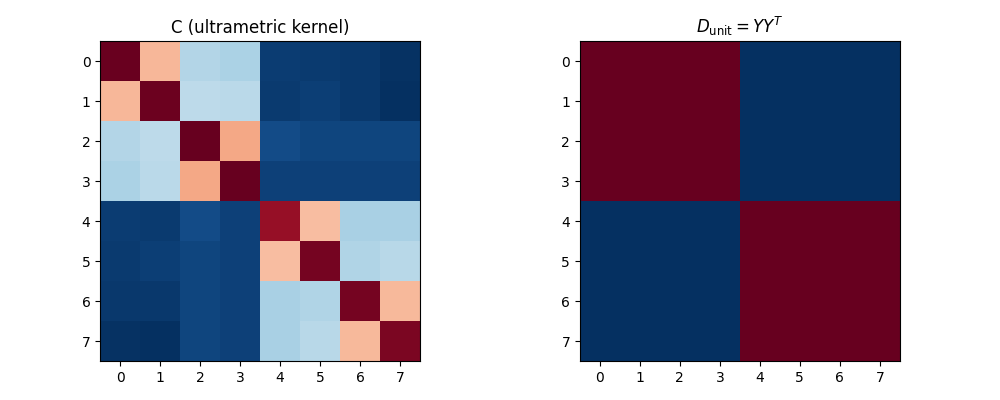

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].set_title('C (ultrametric kernel)'); axes[0].imshow(C, cmap='RdBu_r'); axes[0].set_xticks(range(d)); axes[0].set_yticks(range(d))
axes[1].set_title(r'$D_{\mathrm{unit}} = Y Y^T$'); axes[1].imshow(D_unit, cmap='RdBu_r'); axes[1].set_xticks(range(d)); axes[1].set_yticks(range(d))
plt.tight_layout(); plt.show()

In [16]:
ndtr_fn = lambda beta: lambda h: ndtr(beta * h)
tanh = lambda beta: lambda h: np.tanh(beta * h)

sigmas = np.geomspace(0.01, 10.0, 120)
beta = 100.0

np.random.seed(42)
overlaps_ndtr, ess_ndtr = compute_overlaps(sigmas, ndtr_fn(beta))
np.random.seed(42)
overlaps_tanh, ess_tanh = compute_overlaps(sigmas, tanh(beta))

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

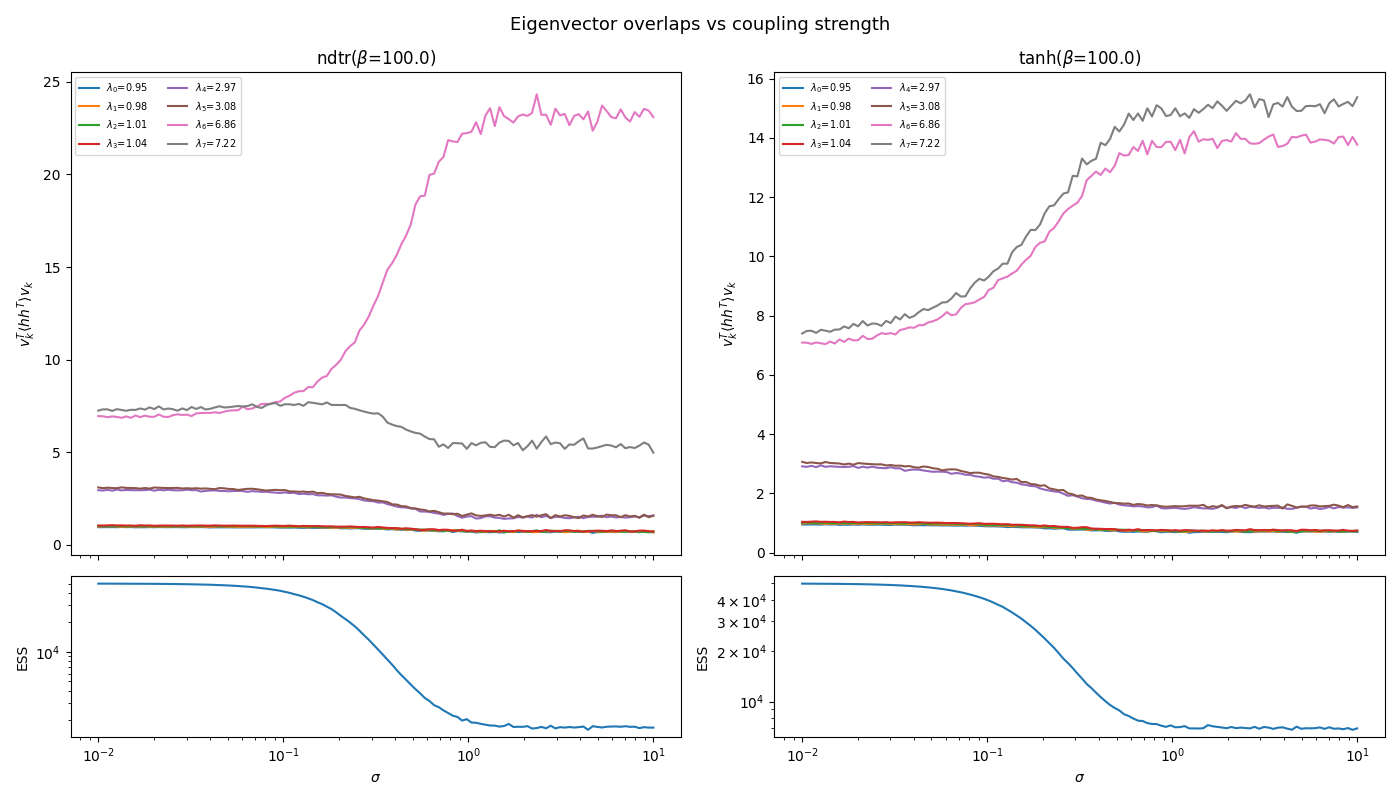

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

for col, (label, overlaps, ess) in enumerate([(f'ndtr($\\beta$={beta})', overlaps_ndtr, ess_ndtr), (f'tanh($\\beta$={beta})', overlaps_tanh, ess_tanh)]):
    for k in range(d):
        axes[0, col].plot(sigmas, overlaps[:, k], label=f'$\\lambda_{k}$={eig_vals[k]:.2f}')
    axes[0, col].set_xscale('log')
    axes[0, col].set_ylabel(r'$v_k^T \langle h h^T \rangle v_k$')
    axes[0, col].set_title(label)
    axes[0, col].legend(fontsize=7, ncol=2)
    axes[1, col].semilogy(sigmas, ess)
    axes[1, col].set_xscale('log')
    axes[1, col].set_xlabel(r'$\sigma$'); axes[1, col].set_ylabel('ESS')

fig.suptitle('Eigenvector overlaps vs coupling strength', fontsize=13)
fig.tight_layout()
plt.show()

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

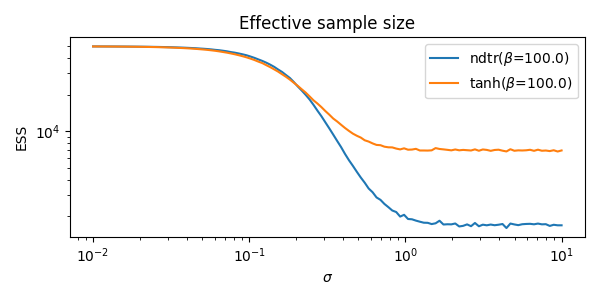

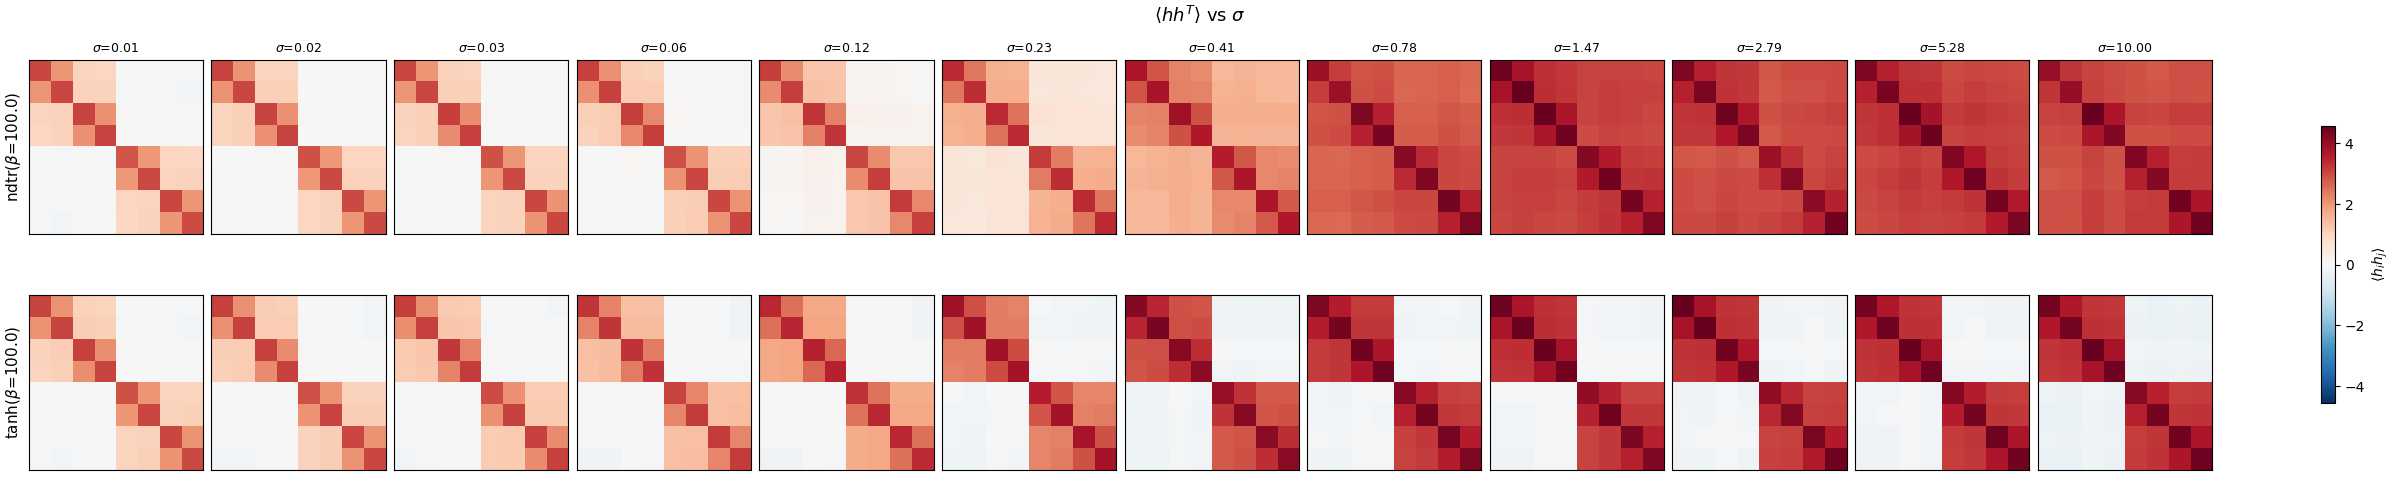

In [18]:
def compute_full_hhT(sigma_values, phi_fn, n_samples=N_SAMPLES):
    """Compute <hh^T> with fresh MC samples per sigma, h ~ N(0, C)."""
    result = np.empty((len(sigma_values), d, d))
    ess = np.empty(len(sigma_values))
    for i, sigma in enumerate(tqdm(sigma_values, leave=False)):
        z = np.random.randn(n_samples, d)
        h = z @ L.T
        phi_h = phi_fn(h)
        log_w = 0.5 * sigma * np.einsum('ni,ij,nj->n', phi_h, D_unit, phi_h)
        log_w -= log_w.max()
        w = np.exp(log_w)
        w /= w.sum()
        ess[i] = 1.0 / np.sum(w ** 2)
        result[i] = np.einsum('n,ni,nj->ij', w, h, h)
    return result, ess

n_sig = len(sigmas)
np.random.seed(42)
hhT_ndtr, ess_ndtr_hh = compute_full_hhT(sigmas, ndtr_fn(beta))
np.random.seed(42)
hhT_tanh, ess_tanh_hh = compute_full_hhT(sigmas, tanh(beta))

# ESS diagnostic
fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(sigmas, ess_ndtr_hh, label=f'ndtr($\\beta$={beta})')
ax.semilogy(sigmas, ess_tanh_hh, label=f'tanh($\\beta$={beta})')
ax.set_xscale('log')
ax.set_xlabel(r'$\sigma$'); ax.set_ylabel('ESS')
ax.set_title('Effective sample size')
ax.legend(); fig.tight_layout(); plt.show()

# Heatmap grid
n_show = min(n_sig, 12)
idx = np.linspace(0, n_sig - 1, n_show, dtype=int)

vlim = max(abs(hhT_ndtr[idx].min()), abs(hhT_ndtr[idx].max()),
           abs(hhT_tanh[idx].min()), abs(hhT_tanh[idx].max()))

fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 5), constrained_layout=True)
for j, si in enumerate(idx):
    for row, (label, data) in enumerate([(f'ndtr($\\beta$={beta})', hhT_ndtr), (f'tanh($\\beta$={beta})', hhT_tanh)]):
        ax = axes[row, j]
        im = ax.imshow(data[si], vmin=-vlim, vmax=vlim, cmap='RdBu_r')
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(f'$\\sigma$={sigmas[si]:.2f}', fontsize=9)
        if j == 0:
            ax.set_ylabel(label, fontsize=11)

fig.colorbar(im, ax=axes, shrink=0.6, label=r'$\langle h_i h_j \rangle$')
fig.suptitle(r'$\langle h h^T \rangle$ vs $\sigma$', fontsize=13)
plt.show()

beta sweep:   0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

...

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

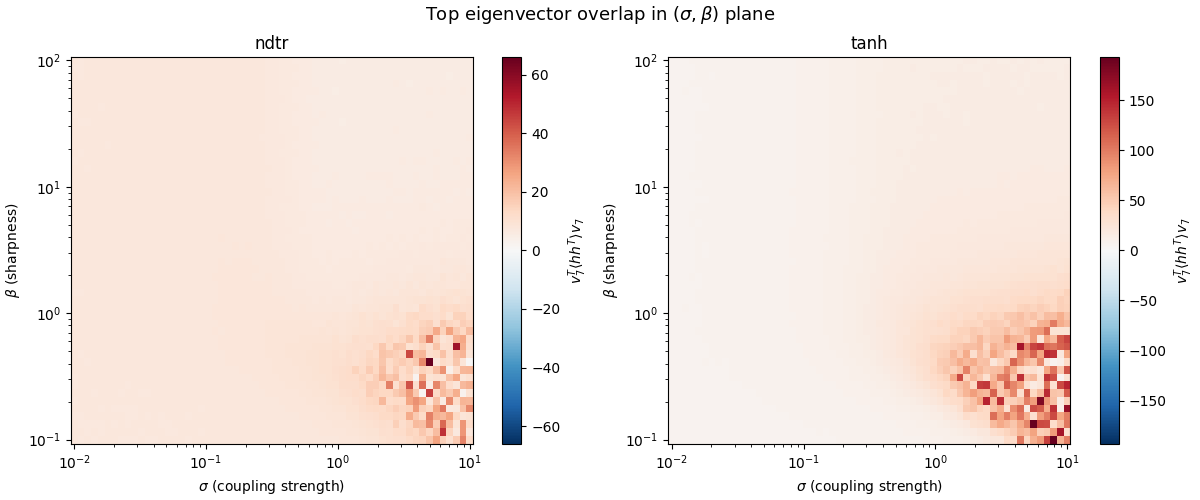

In [20]:
# 2D phase diagram: overlaps in (sigma, beta) plane — use top eigenvector
sigmas_2d = np.geomspace(0.01, 10.0, 60)
betas_2d = np.logspace(-1, 2, 50)

# Store overlap with top eigenvector of C for both activations
phase_top_ndtr = np.empty((len(betas_2d), len(sigmas_2d)))
phase_top_tanh = np.empty((len(betas_2d), len(sigmas_2d)))

np.random.seed(42)
for j, b in enumerate(tqdm(betas_2d, desc='beta sweep')):
    ovl_ndtr, _ = compute_overlaps(sigmas_2d, ndtr_fn(b), n_samples=100_000)
    ovl_tanh, _ = compute_overlaps(sigmas_2d, tanh(b), n_samples=100_000)
    phase_top_ndtr[j] = ovl_ndtr[:, -1]
    phase_top_tanh[j] = ovl_tanh[:, -1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, data, label in zip(axes, [phase_top_ndtr, phase_top_tanh], ['ndtr', 'tanh']):
    vlim = max(abs(data.min()), abs(data.max()))
    im = ax.pcolormesh(sigmas_2d, betas_2d, data, cmap='RdBu_r',
                       vmin=-vlim, vmax=vlim, shading='auto')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$\sigma$ (coupling strength)')
    ax.set_ylabel(r'$\beta$ (sharpness)')
    ax.set_title(label)
    fig.colorbar(im, ax=ax, label=rf'$v_{{{d-1}}}^T \langle hh^T \rangle v_{{{d-1}}}$')
fig.suptitle(f'Top eigenvector overlap in $(\\sigma, \\beta)$ plane', fontsize=13)
plt.show()